<a href="https://colab.research.google.com/github/luvr1/CCMACLRL_EXERCISES/blob/main/Reyes_Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4: Hate Speech Classification using Multinomial Naive Bayes

Instructions:
- You do not need to split your data. Use the training, validation and test sets provided below.
- Use Multinomial Naive Bayes to train a model that can classify if a sentence is a hate speech or non-hate speech
- A sentence with a label of zero (0) is classified as non-hate speech
- A sentence with a label of one (1) is classified as a hate speech

Apply text pre-processing techniques such as
- Converting to lowercase
- Stop word Removal
- Removal of digits, special characters
- Stemming or Lemmatization but not both
- Count Vectorizer or TF-IDF Vectorizer but not both

Evaluate your model by:
- Providing input by yourself
- Creating a Confusion Matrix
- Calculating the Accuracy, Precision, Recall and F1-Score

In [37]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

In [2]:
splits = {'train': 'unique_train_dataset.csv', 'validation': 'unique_validation_dataset.csv', 'test': 'unique_test_dataset.csv'}

**Training Set**

Use this to train your model

In [18]:
df_train = pd.read_csv("hf://datasets/mapsoriano/2016_2022_hate_speech_filipino/" + splits["train"])

**Validation Set**

Use this set to evaluate your model

In [19]:
df_validation = pd.read_csv("hf://datasets/mapsoriano/2016_2022_hate_speech_filipino/" + splits["validation"])

**Test Set**
  
Use this set to test your model

In [20]:
df_test = pd.read_csv("hf://datasets/mapsoriano/2016_2022_hate_speech_filipino/" + splits["test"])

## A. Understanding your training data

1. Check the first 10 rows of the training dataset

In [21]:
print(df_test.head(10))

                                                text  label
0  Binay: Patuloy ang kahirapan dahil sa maling p...      0
1  SA GOBYERNONG TAPAT WELCOME SA BAGUO ANG LAHAT...      0
2  wait so ur telling me Let Leni Lead mo pero NY...      1
3   [USERNAME]wish this is just a nightmare that ...      0
4               doc willie ong and isko sabunutan po      0
5    Jeonghan said Let Leni Lead!! Lenihae ahahhdjfj      0
6  [USERNAME] [USERNAME]and[USERNAME] Hahahhahaha...      1
7  [USERNAME] Attendees of the CNNPHVPDebate are ...      0
8  Abscbn News Hoaxnews ng abias cbend baklas pos...      1
9  NEWS UPDATE: The camp of VP Leni Robredo says ...      0


2. Check how many rows and columns are in the training dataset using `.info()`

In [22]:
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2810 non-null   object
 1   label   2810 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 44.0+ KB
None


3. Check for NaN values

*   List item
*   List item



In [23]:
print(df_test.isnull().sum())
df_test.isnull().values.any()
df_test[df_test.isnull().any(axis=1)]

text     0
label    0
dtype: int64


,text,label


4. Check for duplicate rows

In [24]:
df_test.duplicated().sum()
df_test[df_test.duplicated()]

,text,label


5. Check how many rows belong to each class

In [25]:
print(df_test['label'].value_counts())

label
0    1412
1    1398
Name: count, dtype: int64


## B. Text pre-processing

6. Remove duplicate rows

In [29]:
df_test = df_test.drop_duplicates()

7. Remove rows with NaN values

In [30]:
df_test = df_test.dropna()

8. Convert all text to lowercase

In [32]:
df_test['text'] = df_test['text'].str.lower()
print(df_test.head())

                                                text  label
0  binay: patuloy ang kahirapan dahil sa maling p...      0
1  sa gobyernong tapat welcome sa baguo ang lahat...      0
2  wait so ur telling me let leni lead mo pero ny...      1
3   [username]wish this is just a nightmare that ...      0
4               doc willie ong and isko sabunutan po      0


9. Remove digits, URLS and special characters

In [36]:
def clean_text(text):
    # Remove digits
    text = re.sub(r'\d+', '', text)
    # Remove URLS
    text = re.sub(r'http\S+', '', text)
    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)
    return text

df_test['text'] = df_test['text'].apply(clean_text)
print(df_test.head())

                                                text  label
0  binay patuloy ang kahirapan dahil sa maling pa...      0
1  sa gobyernong tapat welcome sa baguo ang lahat...      0
2  wait so ur telling me let leni lead mo pero ny...      1
3   usernamewish this is just a nightmare that co...      0
4               doc willie ong and isko sabunutan po      0


10. Remove stop words

In [39]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df_test['text'] = df_test['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
print(df_test.head())

                                                text  label
0  binay patuloy ang kahirapan dahil sa maling pa...      0
1  sa gobyernong tapat welcome sa baguo ang lahat...      0
2  wait ur telling let leni lead mo pero nyong uy...      1
3  usernamewish nightmare could end pa failed let...      0
4                   doc willie ong isko sabunutan po      0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


11. Use Stemming or Lemmatization

In [40]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
df_test['text'] = df_test['text'].apply(lambda x: ' '.join([stemmer.stem(word) for word in x.split()]))
print(df_test.head())

                                                text  label
0  binay patuloy ang kahirapan dahil sa male pama...      0
1  sa gobyernong tapat welcom sa baguo ang lahat ...      0
2  wait ur tell let leni lead mo pero nyong uyab ...      1
3  usernamewish nightmar could end pa fail let le...      0
4                    doc willi ong isko sabunutan po      0


## C. Training your model

12. Put all text training data in variable **X_train**

In [41]:
X_train = df_train['text']
print(X_train.head())

0    Presidential candidate Mar Roxas implies that ...
1    Parang may mali na sumunod ang patalastas ng N...
2                      Bet ko. Pula Ang Kulay Ng Posas
3                                 [USERNAME] kakampink
4    Bakit parang tahimik ang mga PINK about Doc Wi...
Name: text, dtype: object


13. Put all training data labels in variable **y_train**

In [42]:
y_train = df_train['label']
print(y_train.head())

0    1
1    1
2    1
3    0
4    1
Name: label, dtype: int64


14. Use `CountVectorizer()` or `TfidfVectorizer()` to convert text data to its numerical form.

Put the converted data to **X_train_transformed** variable

In [44]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_train_transformed = vectorizer.fit_transform(X_train)
print(X_train_transformed.toarray())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


15. Create an instance of `MultinomalNB()`

In [45]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

16. Train the model using `.fit()`

In [46]:
model.fit(X_train_transformed, y_train)

MultinomialNB()

## D. Evaluate your model

17. Use `.predict()` to generate model predictions using the **validation dataset**


- Put all text validation data in **X_validation** variable

- Convert **X_validation** to its numerical form.

- Put the converted data to **X_validation_transformed**

- Put all predictions in **y_validation_pred** variable

In [48]:
X_validation = df_validation['text']
y_validation = df_validation['label']
X_validation_transformed = vectorizer.transform(X_validation)
y_validation_pred = model.predict(X_validation_transformed)
print(y_validation_pred)


[1 0 0 ... 0 0 1]


18. Get the Accuracy, Precision, Recall and F1-Score of the model using the **validation dataset**

- Put all validation data labels in **y_validation** variable

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_validation, y_validation_pred)
precision = precision_score(y_validation, y_validation_pred)
recall = recall_score(y_validation, y_validation_pred)
f1 = f1_score(y_validation, y_validation_pred)
y_validation = df_validation['label']

19. Create a confusion matrix using the **validation dataset**

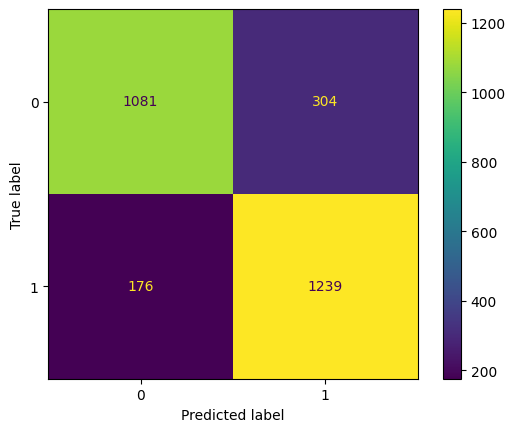

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_validation, y_validation_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

20. Use `.predict()` to generate the model predictions using the **test dataset**


- Put all text validation data in **X_test** variable

- Convert **X_test** to its numerical form.

- Put the converted data to **X_test_transformed**

- Put all predictions in **y_test_pred** variable

In [58]:
test_df = pd.read_csv("hf://datasets/mapsoriano/2016_2022_hate_speech_filipino/" + splits["test"])
X_test = test_df['text']
y_test = test_df['label']
X_test_transformed = vectorizer.transform(X_test)
y_test_pred = model.predict(X_test_transformed)
print(y_test_pred)

[1 0 1 ... 1 0 1]


21. Get the Accuracy, Precision, Recall and F1-Score of the model using the **test dataset**

- Put all test data labels in **y_validation** variable



In [59]:
y_validation = test_df['label']
accuracy = accuracy_score(y_validation, y_test_pred)
precision = precision_score(y_validation, y_test_pred)
recall = recall_score(y_validation, y_test_pred)
f1 = f1_score(y_validation, y_test_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.8249110320284697
Precision: 0.7945383615084526
Recall: 0.8741058655221745
F1-Score: 0.832425068119891


22. Create a confusion matrix using the **test dataset**

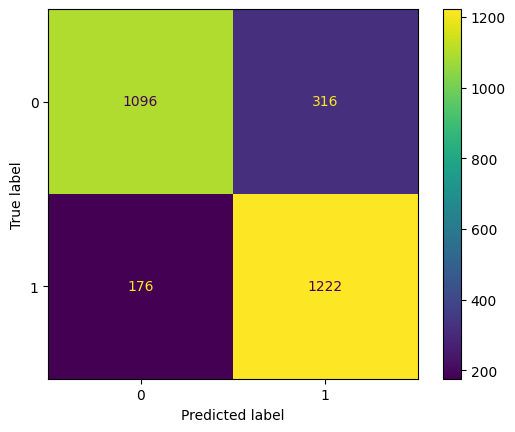

In [60]:
cm = confusion_matrix(y_validation, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

## E. Test the model

23. Test the model by providing a non-hate speech input. The model should predict it as 0

In [86]:
not_a_hater = ["Kitakits sa Sept.21"]
not_hate_text_transformed = vectorizer.transform(not_a_hater)
prediction = model.predict(not_hate_text_transformed)
print("Prediction:", prediction[0])

Prediction: 0


24. Test the model by providing a hate speech input. The model should predict it as 1

In [87]:
hater_kano = ["DPWH PALPAK TAPOS YUNG ISA PERFORMATIVE"]
hate_text_transformed = vectorizer.transform(hater_kano)
prediction = model.predict(hate_text_transformed)
print("Prediction:", prediction[0])

Prediction: 1
